# UDA Project — Training e valutazione su Google Colab

Questo notebook raccoglie tutti gli esperimenti del progetto eseguiti su Google Colab con GPU NVIDIA T4: training della baseline, delle tecniche di Unsupervised Domain Adaptation (CORAL, DANN, DANN stabilizzato, self-training) e visualizzazioni t-SNE. Gli output mostrati sono quelli delle esecuzioni reali, svolte in più sessioni.

L'analisi di robustezza e il color matching sono stati eseguiti in locale (vedi README).

**Preparazione:**
1. Creare uno zip della cartella del progetto `progetto-uda-deeplearning` (con `data/source` e `data/target` già preparati) e caricarlo su Google Drive, ad esempio in `MyDrive/ProgettoDeepLearning/`.
2. In Colab: `Runtime` → `Cambia tipo di runtime` → **GPU (T4)**.

⚠️ Lo storage di Colab (`/content/`) è temporaneo: le celle di salvataggio copiano checkpoint, log e figure su Google Drive al termine di ogni esperimento.

## 1. Verifica della GPU

In [ ]:
import torch
print("GPU disponibile:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Nome GPU:", torch.cuda.get_device_name(0))
else:
    print("ATTENZIONE: nessuna GPU rilevata. Vai su Runtime -> Cambia tipo di runtime -> GPU (T4), poi riesegui questa cella.")

GPU disponibile: True
Nome GPU: Tesla T4


## 2. Montaggio di Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Estrazione del progetto dallo zip su Drive

Modificare `DRIVE_ZIP_PATH` se lo zip si trova in un'altra cartella.

In [ ]:
DRIVE_ZIP_PATH = "/content/drive/MyDrive/ProgettoDeepLearning/progetto-uda-deeplearning.zip"
PROJECT_DIR = "/content/progetto-uda-deeplearning"

!rm -rf {PROJECT_DIR}
!unzip -q "{DRIVE_ZIP_PATH}" -d /content/
%cd {PROJECT_DIR}
!ls

/content/progetto-uda-deeplearning
CONTRIBUTING.md  environment.yml  INSTRUCTIONS.md  README.md
data		 experiments	  LICENSE	   src
docs		 figures	  notebooks	   UDA_Colab_Training.ipynb


## 4. Dipendenze

Colab include già PyTorch e la maggior parte delle librerie necessarie.

In [ ]:
!pip install -q pyyaml tqdm scikit-learn

## 5. Baseline (ResNet-18)

### 5.1 Training sul source

In [ ]:
!python -m src.training.train_baseline --config experiments/configs/baseline.yaml

Device in uso: cuda
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Classi (class_to_idx): {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 176MB/s]
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller t

### 5.2 Valutazione su source e target

**Nota:** questa valutazione è stata eseguita prima del ridimensionamento offline delle immagini target (sezione 6), e riporta quindi 73,88% sul target. Rieseguita sulle immagini ridimensionate, le stesse usate per tutti gli altri modelli, la baseline raggiunge il **74,05%**: è questo il valore di riferimento usato nel report.

In [ ]:
!python -m src.evaluation.evaluate_domain_shift --config experiments/configs/baseline.yaml

Device in uso: cuda
Checkpoint caricato (val_acc al training: 0.9273, epoca 5)
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  se

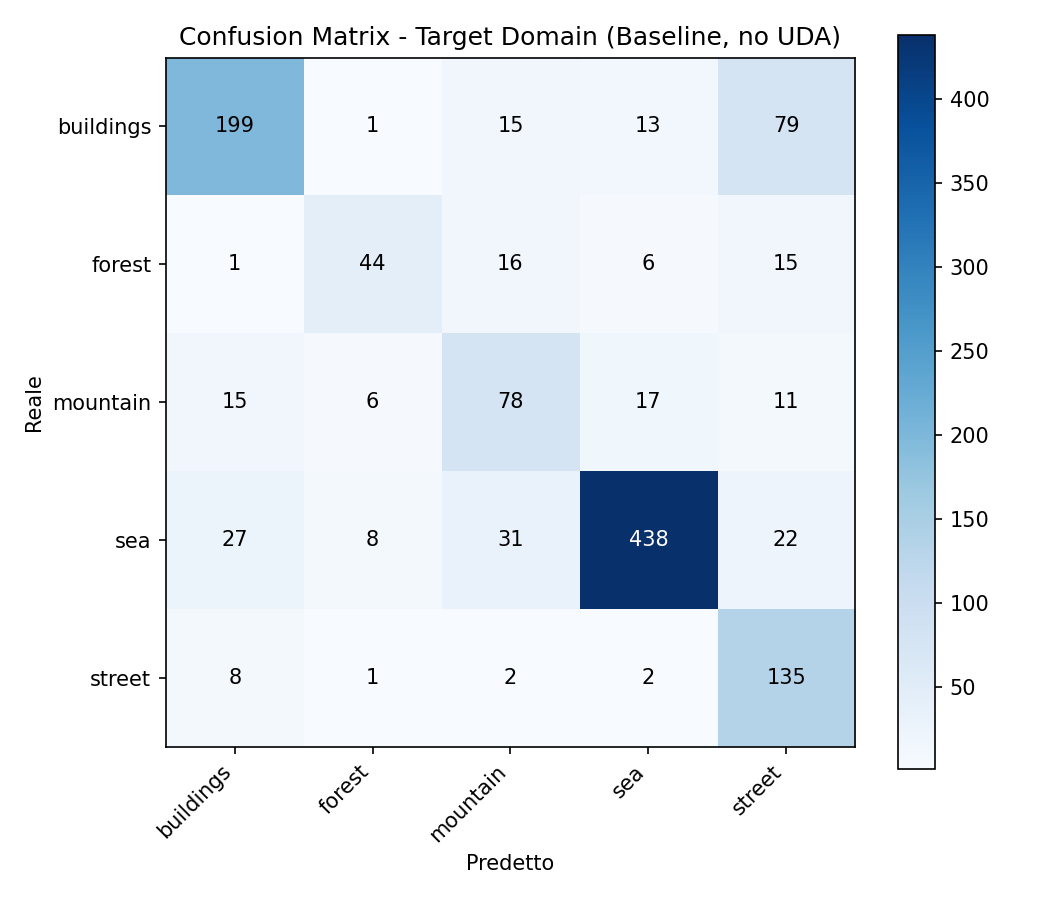

In [ ]:
from IPython.display import Image, display
display(Image(filename="figures/confusion_matrix_target_baseline.png"))

### 5.3 Salvataggio dei risultati su Drive

In [ ]:
RESULTS_DEST = "/content/drive/MyDrive/ProgettoDeepLearning/results_baseline"

!mkdir -p "{RESULTS_DEST}"
!cp -r experiments/checkpoints "{RESULTS_DEST}/"
!cp -r experiments/logs "{RESULTS_DEST}/"
!cp -r figures "{RESULTS_DEST}/"

print(f"Risultati baseline salvati in Google Drive: {RESULTS_DEST}")

## 6. Preparazione per CORAL e DANN

### 6.1 Test di velocità della GPU (diagnostica, facoltativo)

Misura il solo calcolo della GPU su un tensore casuale, senza caricamento dei dati. È servito a scoprire che la lentezza iniziale del training CORAL (oltre 5 secondi per iterazione) non dipendeva dalla GPU ma dal caricamento delle immagini.

In [ ]:
import torch, time
from src.models.baseline import get_baseline_model

model = get_baseline_model(num_classes=6).cuda()
x = torch.randn(32, 3, 224, 224).cuda()

torch.cuda.synchronize()
start = time.time()
for _ in range(20):
    y = model(x)
torch.cuda.synchronize()

print(f"{(time.time() - start) / 20:.4f} sec/iterazione (solo calcolo GPU, niente dati)")

0.0395 sec/iterazione (solo calcolo GPU, niente dati)


### 6.2 Ridimensionamento offline delle immagini target

CORAL e DANN rileggono il target molte volte per epoca: decodificare le foto a piena risoluzione rallentava il training di circa 10 volte. Le immagini vengono ridimensionate una sola volta a 224×224. Non serve eseguire questa cella se lo zip contiene già le immagini ridimensionate.

In [ ]:
!python -m src.utils.resize_target_images --target-dir data/target

## 7. CORAL

Training (warm start dalla baseline) e valutazione.

In [ ]:
!python -m src.training.train_coral --config experiments/configs/coral.yaml
!python -m src.evaluation.evaluate_domain_shift --config experiments/configs/coral.yaml

Device in uso: cuda
Classi (class_to_idx): {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
[INFO] Classi del source assenti nel target: ['glacier'] (atteso per classi non riproducibili localmente, es. glacier)
Pesi inizializzati da checkpoint baseline: experiments/checkpoints/baseline_resnet18_best.pth
[Epoch 1/15] cls_loss=0.1254 coral_loss=0.0096 train_acc=0.9555 | val_acc=0.9300 | target_acc (monitor)=0.7223 | 193.8s
  -> Nuovo miglior checkpoint salvato (val_acc=0.9300, target_acc_monitor=0.7223)
[Epoch 2/15] cls_loss=0.0971 coral_loss=0.0070 train_acc=0.9660 | val_acc=0.9280 | target_acc (monitor)=0.7041 | 180.1s
[Epoch 3/15] cls_loss=0.0798 coral_loss=0.0057 train_acc=0.9706 | val_acc=0.9150 | target_acc (monitor)=0.7124 | 179.2s
[Epoch 4/15] cls_loss=0.0740 coral_loss=0.0052 train_acc=0.9739 | val_acc=0.9273 | target_acc (monitor)=0.7058 | 178.9s
[Epoch 5/15] cls_loss=0.0602 coral_loss=0.0045 train_acc=0.9786 | val_acc=0.9067 | target_acc (monit

In [ ]:
RESULTS_DEST = "/content/drive/MyDrive/ProgettoDeepLearning/results_coral"
!mkdir -p "{RESULTS_DEST}"
!cp -r experiments/checkpoints "{RESULTS_DEST}/"
!cp -r experiments/logs "{RESULTS_DEST}/"
!cp -r figures "{RESULTS_DEST}/"

## 8. DANN

### 8.1 Training

In [ ]:
!python -m src.training.train_dann --config experiments/configs/dann.yaml

Device in uso: cuda
Classi (class_to_idx): {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
[INFO] Classi del source assenti nel target: ['glacier'] (atteso per classi non riproducibili localmente, es. glacier)
Pesi inizializzati da checkpoint baseline: experiments/checkpoints/baseline_resnet18_best.pth
[Epoch 1/15] cls_loss=0.1320 domain_loss=1.2971 train_acc=0.9525 | val_acc=0.9183 | target_acc (monitor)=0.6818 | 189.5s
  -> Nuovo miglior checkpoint salvato (val_acc=0.9183, target_acc_monitor=0.6818)
[Epoch 2/15] cls_loss=0.0973 domain_loss=1.4017 train_acc=0.9656 | val_acc=0.9243 | target_acc (monitor)=0.7207 | 177.7s
  -> Nuovo miglior checkpoint salvato (val_acc=0.9243, target_acc_monitor=0.7207)
[Epoch 3/15] cls_loss=0.0846 domain_loss=1.3926 train_acc=0.9715 | val_acc=0.9157 | target_acc (monitor)=0.7041 | 179.4s
[Epoch 4/15] cls_loss=0.0673 domain_loss=1.3906 train_acc=0.9767 | val_acc=0.9297 | target_acc (monitor)=0.6835 | 178.3s
  -> Nuovo mig

### 8.2 Valutazione

In [ ]:
!python -m src.evaluation.evaluate_domain_shift --config experiments/configs/dann.yaml

Device in uso: cuda
Checkpoint caricato (val_acc al training: 0.9350, epoca 11)
[INFO] Classi del source assenti nel target: ['glacier'] (atteso per classi non riproducibili localmente, es. glacier)

RISULTATO: QUANTIFICAZIONE DEL DOMAIN SHIFT
Accuracy su SOURCE val set : 93.50%
Accuracy su TARGET (foto tue): 69.92%
Degrado di performance     : 23.58 punti percentuali

--- Accuracy per classe (SOURCE val) ---
  buildings   : 91.76%  (n=437)
  forest      : 99.16%  (n=474)
  glacier     : 89.15%  (n=553)
  mountain    : 90.67%  (n=525)
  sea         : 95.88%  (n=510)
  street      : 95.01%  (n=501)

--- Accuracy per classe (TARGET) ---
  buildings   : 62.99%  (n=308)
  forest      : 64.29%  (n=84)
  mountain    : 47.86%  (n=140)
  sea         : 81.25%  (n=528)
  street      : 68.00%  (n=150)

[NOTA] Classi assenti nel target (non riproducibili localmente): ['glacier']
Confusion matrix salvata in: figures/confusion_matrix_target_baseline.png

--- Classification report dettagliato (TARGET

### 8.3 Salvataggio

In [ ]:
RESULTS_DEST = "/content/drive/MyDrive/ProgettoDeepLearning/results_dann"

!mkdir -p "{RESULTS_DEST}"
!cp -r experiments/checkpoints "{RESULTS_DEST}/"
!cp -r experiments/logs "{RESULTS_DEST}/"
!cp -r figures "{RESULTS_DEST}/"

print(f"Risultati DANN salvati in Google Drive: {RESULTS_DEST}")

Risultati DANN salvati in Google Drive: /content/drive/MyDrive/ProgettoDeepLearning/results_dann


## 9. DANN stabilizzato

Stessa architettura di DANN con pressione avversariale ridotta: γ = 5, λ massimo 0,3, peso della loss di dominio 0,5.

### 9.1 Training

In [ ]:
!python -m src.training.train_dann_stable --config experiments/configs/dann_stable.yaml

Device in uso: cuda
Classi (class_to_idx): {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
[INFO] Classi del source assenti nel target: ['glacier'] (atteso per classi non riproducibili localmente, es. glacier)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 178MB/s]
Pesi inizializzati da checkpoint baseline: experiments/checkpoints/baseline_resnet18_best.pth
GRL: gamma=5.0, max_lambda=0.3, domain_loss_weight=0.5
[Epoch 1/15] cls_loss=0.1270 domain_loss=0.4786 train_acc=0.9540 | val_acc=0.9223 | target_acc (monitor)=0.7041 | 198.6s
  -> Nuovo miglior checkpoint salvato (val_acc=0.9223, target_acc_monitor=0.7041)
[Epoch 2/15] cls_loss=0.0961 domain_loss=0.5237 train_acc=0.9644 | val_acc=0.9293 | target_acc (monitor)=0.7298 | 216.7s
  -> Nuovo miglior checkpoint salvato (val_acc=0.9293, target_acc_monitor=0.7298)
[Epoch 3/15] cls_loss=0.0838

### 9.2 Valutazione

In [ ]:
!python -m src.evaluation.evaluate_domain_shift --config experiments/configs/dann_stable.yaml

Device in uso: cuda
Checkpoint caricato (val_acc al training: 0.9353, epoca 11)
[INFO] Classi del source assenti nel target: ['glacier'] (atteso per classi non riproducibili localmente, es. glacier)

RISULTATO: QUANTIFICAZIONE DEL DOMAIN SHIFT
Accuracy su SOURCE val set : 93.53%
Accuracy su TARGET (foto tue): 67.02%
Degrado di performance     : 26.51 punti percentuali

--- Accuracy per classe (SOURCE val) ---
  buildings   : 91.08%  (n=437)
  forest      : 99.16%  (n=474)
  glacier     : 91.14%  (n=553)
  mountain    : 88.57%  (n=525)
  sea         : 95.69%  (n=510)
  street      : 96.01%  (n=501)

--- Accuracy per classe (TARGET) ---
  buildings   : 58.77%  (n=308)
  forest      : 59.52%  (n=84)
  mountain    : 45.71%  (n=140)
  sea         : 78.98%  (n=528)
  street      : 66.00%  (n=150)

[NOTA] Classi assenti nel target (non riproducibili localmente): ['glacier']
Confusion matrix salvata in: figures/confusion_matrix_target_baseline.png

--- Classification report dettagliato (TARGET

### 9.3 Salvataggio

In [ ]:
RESULTS_DEST = "/content/drive/MyDrive/ProgettoDeepLearning/results_dann_stable"

!mkdir -p "{RESULTS_DEST}"
!cp -r experiments/checkpoints "{RESULTS_DEST}/"
!cp -r experiments/logs "{RESULTS_DEST}/"
!cp -r figures "{RESULTS_DEST}/"

print(f"Risultati DANN stabilizzato salvati in Google Drive: {RESULTS_DEST}")

Risultati DANN stabilizzato salvati in Google Drive: /content/drive/MyDrive/ProgettoDeepLearning/results_dann_stable


## 10. Self-training con pseudo-label

Il modello CORAL fa da insegnante e genera pseudo-label sul target (confidenza ≥ 0,9).

### 10.1 Training

In [ ]:
!python -m src.training.train_self_training --config experiments/configs/self_training.yaml

Device in uso: cuda
Classi (class_to_idx): {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
[INFO] Classi del source assenti nel target: ['glacier'] (atteso per classi non riproducibili localmente, es. glacier)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 133MB/s]
Modello insegnante caricato da: experiments/checkpoints/coral_resnet18_best.pth
  Pseudo-label selezionate: 943/1210 (77.9%) con confidenza >= 0.9
  [SOLO ANALISI, non usato nel training] Accuracy delle pseudo-label selezionate rispetto alle vere etichette: 82.61%
  [SOLO ANALISI] Dettaglio per classe vera (quante selezionate / totale, e purezza):
    buildings   : 239/308 selezionate, purezza 89.1%
    forest      : 45/84 selezionate, purezza 64.4%
    mountain    : 91/140 selezionate, purezza 47.3%
    sea         : 454/528 selezionate, purezza 88.8%
    street      : 114/15

### 10.2 Valutazione

In [ ]:
!python -m src.evaluation.evaluate_domain_shift --config experiments/configs/self_training.yaml

Device in uso: cuda
Checkpoint caricato (val_acc al training: 0.9380, epoca 6)
[INFO] Classi del source assenti nel target: ['glacier'] (atteso per classi non riproducibili localmente, es. glacier)

RISULTATO: QUANTIFICAZIONE DEL DOMAIN SHIFT
Accuracy su SOURCE val set : 93.80%
Accuracy su TARGET (foto tue): 75.95%
Degrado di performance     : 17.85 punti percentuali

--- Accuracy per classe (SOURCE val) ---
  buildings   : 92.22%  (n=437)
  forest      : 98.95%  (n=474)
  glacier     : 86.08%  (n=553)
  mountain    : 92.57%  (n=525)
  sea         : 97.84%  (n=510)
  street      : 96.01%  (n=501)

--- Accuracy per classe (TARGET) ---
  buildings   : 80.19%  (n=308)
  forest      : 63.10%  (n=84)
  mountain    : 47.14%  (n=140)
  sea         : 83.14%  (n=528)
  street      : 76.00%  (n=150)

[NOTA] Classi assenti nel target (non riproducibili localmente): ['glacier']
Confusion matrix salvata in: figures/confusion_matrix_target_baseline.png

--- Classification report dettagliato (TARGET)

### 10.3 Salvataggio

In [ ]:
RESULTS_DEST = "/content/drive/MyDrive/ProgettoDeepLearning/results_self_training"
!mkdir -p "{RESULTS_DEST}"
!cp -r experiments/checkpoints "{RESULTS_DEST}/"
!cp -r experiments/logs "{RESULTS_DEST}/"
!cp -r figures "{RESULTS_DEST}/"
print(f"Risultati self-training salvati in: {RESULTS_DEST}")

Risultati self-training salvati in: /content/drive/MyDrive/ProgettoDeepLearning/results_self_training


## 11. Visualizzazione t-SNE delle feature

### 11.1 Colorazione per dominio

In [ ]:
!python -m src.evaluation.visualize_tsne --source-dir data/source --target-dir data/target --output figures/tsne_comparison.png

Device in uso: cuda
Campione source: 900 immagini
[INFO] Classi del source assenti nel target: ['glacier'] (atteso per classi non riproducibili localmente, es. glacier)
Immagini target: 1210

=== Baseline ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 174MB/s]
  Eseguo t-SNE su 2110 punti...

=== CORAL ===
  Eseguo t-SNE su 2110 punti...

=== DANN ===
  Eseguo t-SNE su 2110 punti...

=== DANN stabilizzato ===
  Eseguo t-SNE su 2110 punti...

[SUCCESS] Figura salvata in: figures/tsne_comparison.png


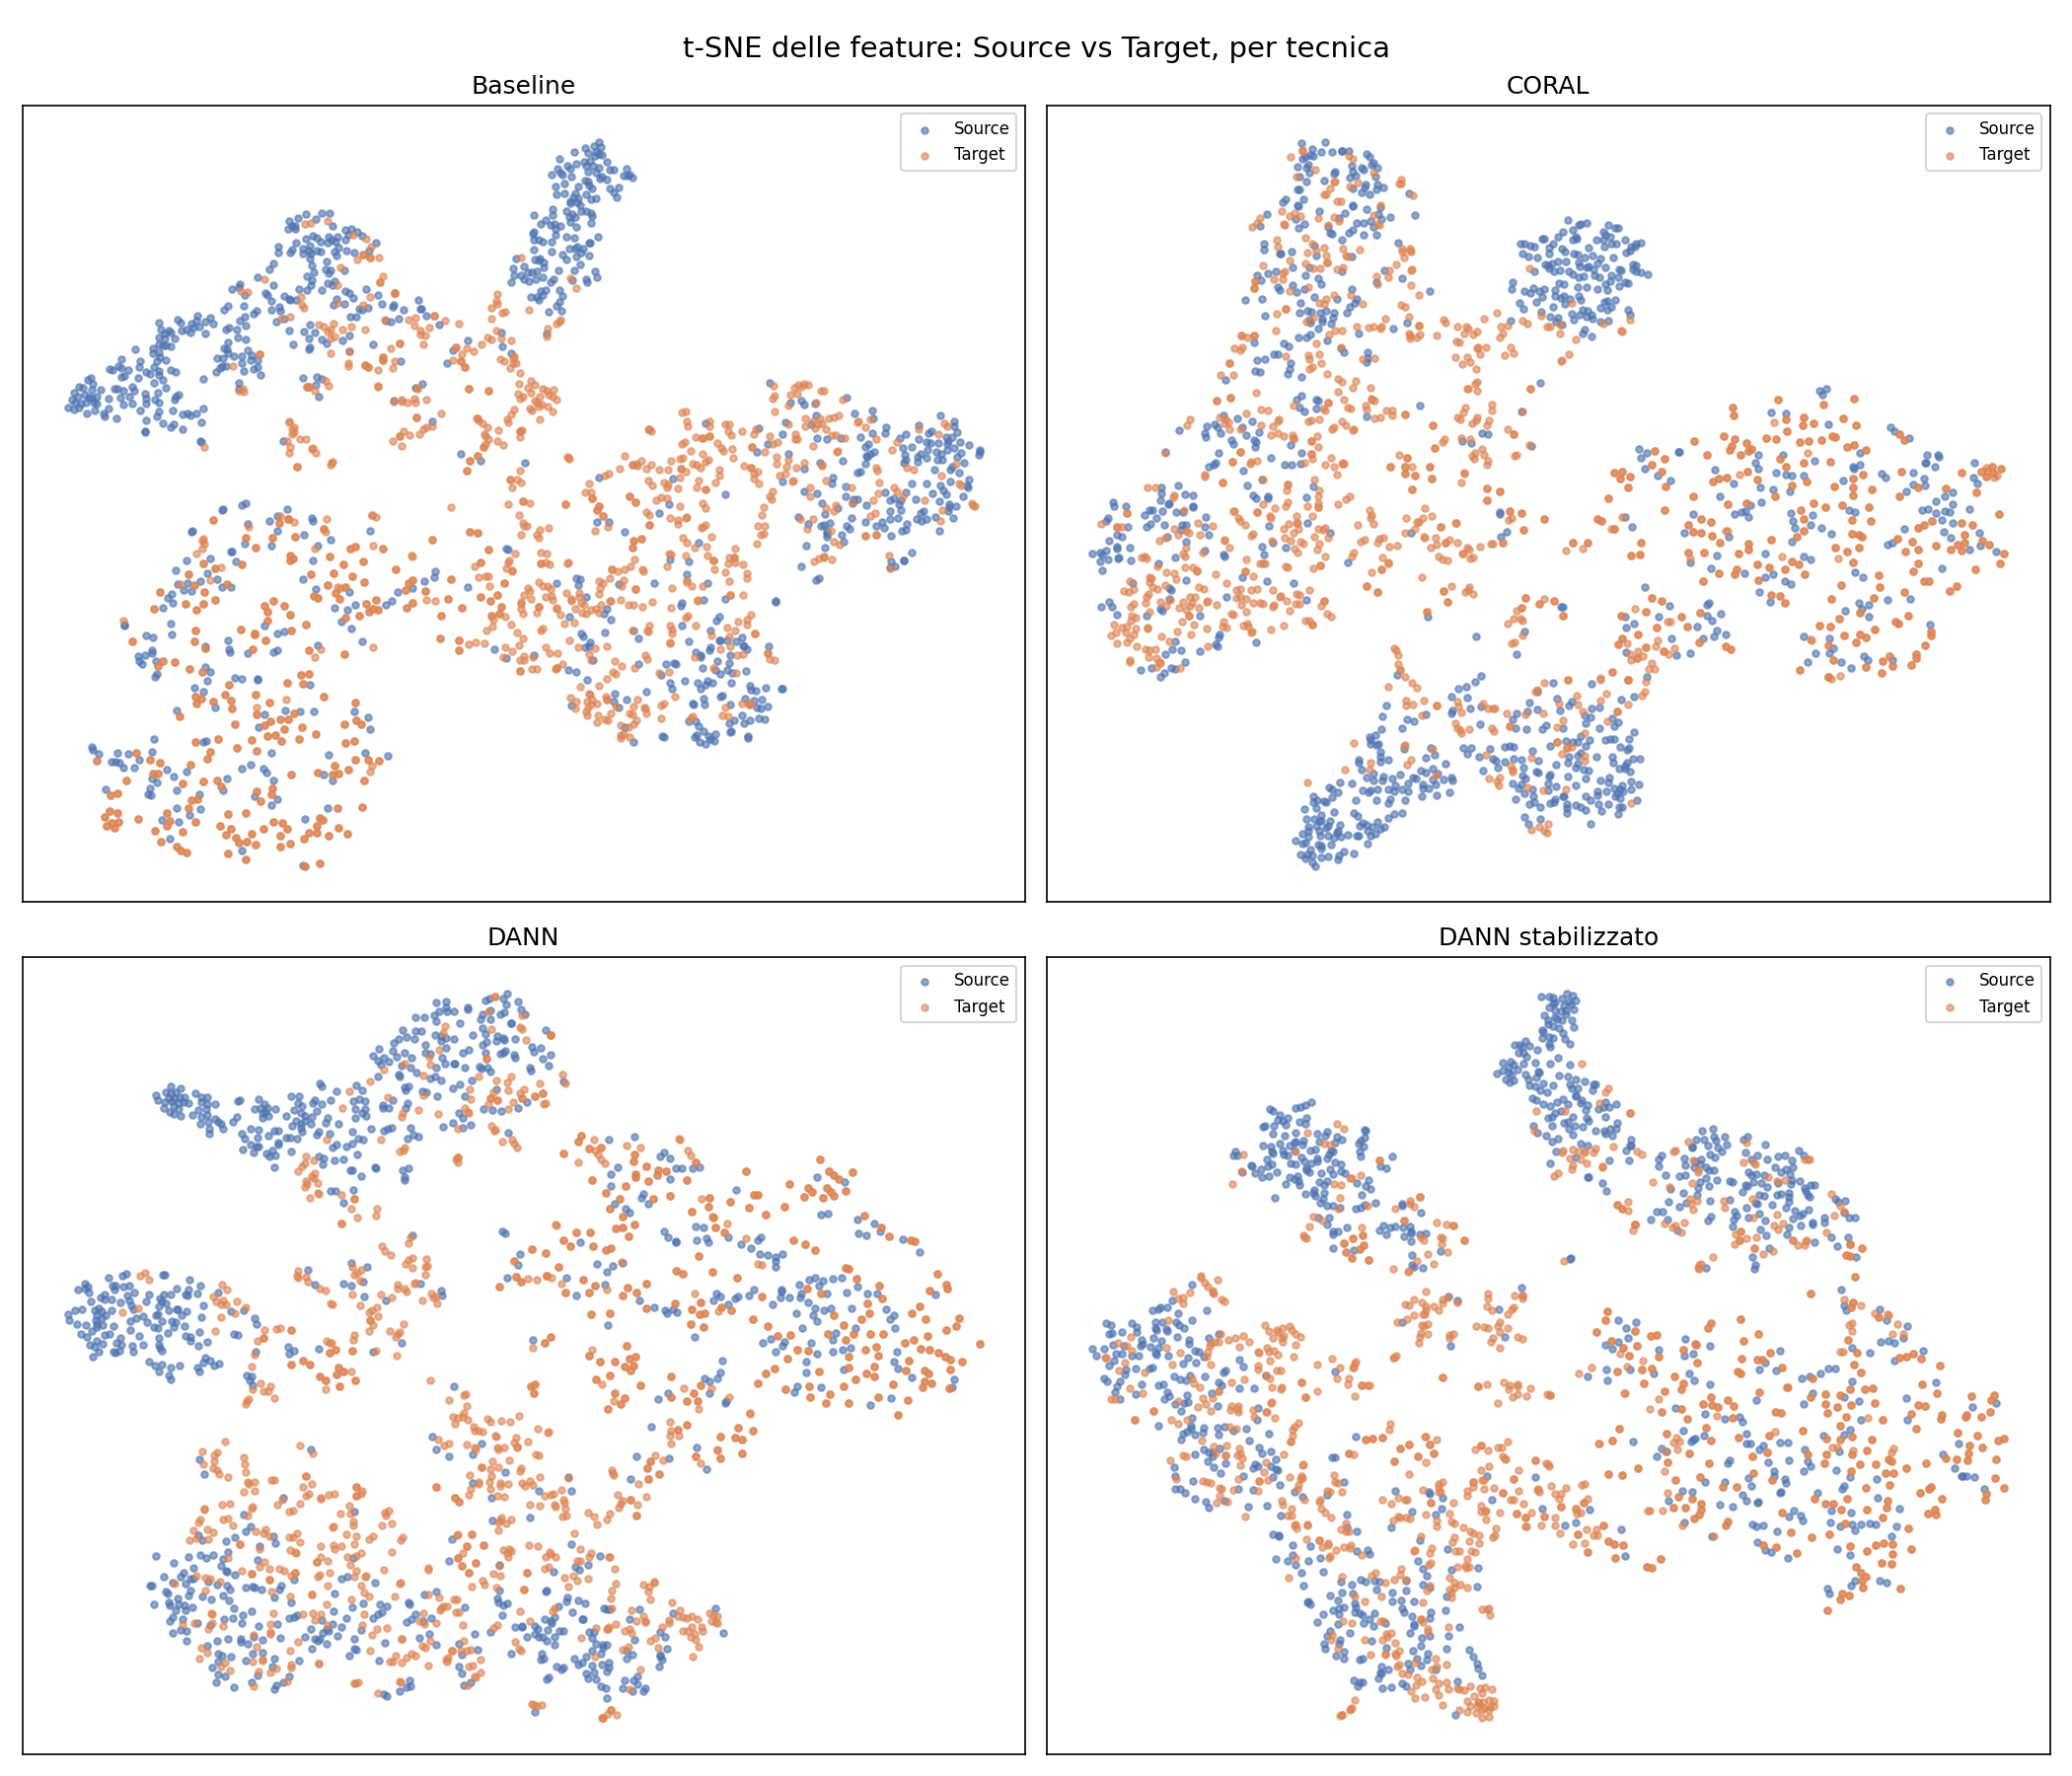

In [ ]:
from IPython.display import Image, display
display(Image(filename="figures/tsne_comparison.png"))

### 11.2 Colorazione per classe

In [ ]:
!python -m src.evaluation.visualize_tsne_by_class --source-dir data/source --target-dir data/target --output figures/tsne_by_class.png

Device in uso: cuda
Campione source: 900 immagini
[INFO] Classi del source assenti nel target: ['glacier'] (atteso per classi non riproducibili localmente, es. glacier)
Immagini target: 1210

=== Baseline ===
  Eseguo t-SNE su 2110 punti...

=== CORAL ===
  Eseguo t-SNE su 2110 punti...

=== DANN ===
  Eseguo t-SNE su 2110 punti...

=== DANN stabilizzato ===
  Eseguo t-SNE su 2110 punti...

[SUCCESS] Figura salvata in: figures/tsne_by_class.png


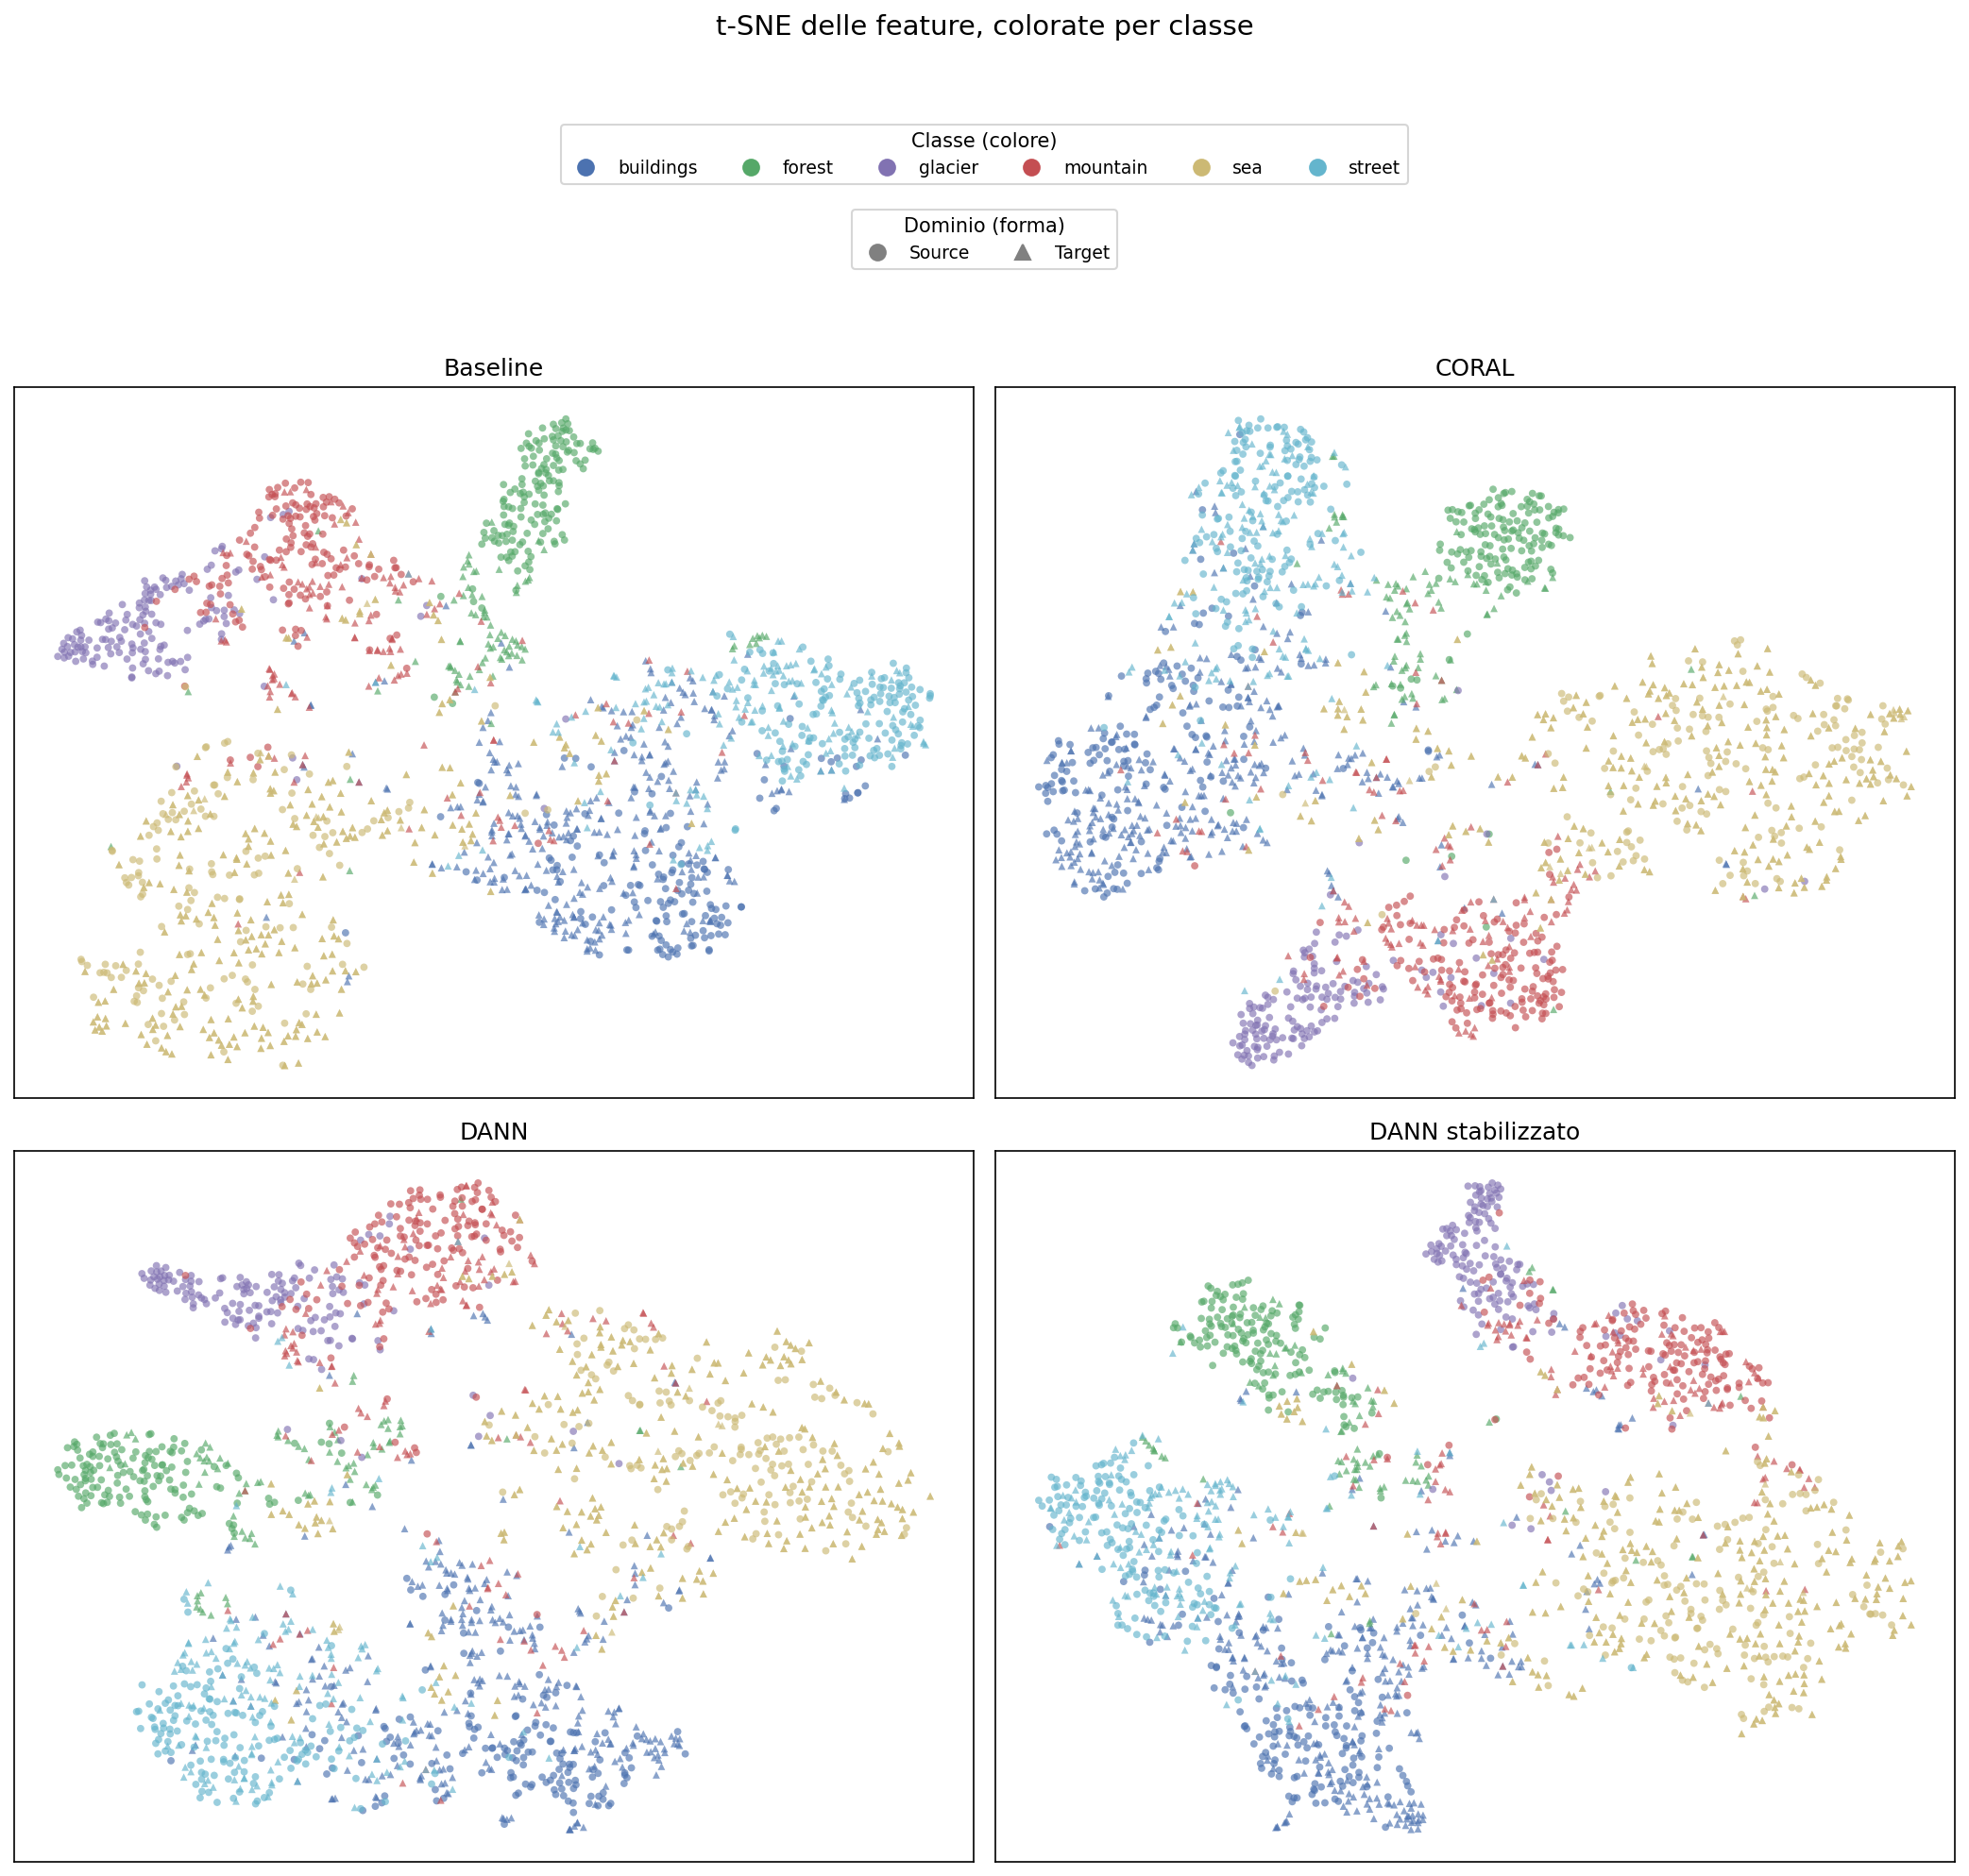

In [ ]:
from IPython.display import Image, display
display(Image(filename="figures/tsne_by_class.png"))

### 11.3 Salvataggio

In [ ]:
RESULTS_DEST = "/content/drive/MyDrive/ProgettoDeepLearning/results_tsne"

!mkdir -p "{RESULTS_DEST}"
!cp -r figures "{RESULTS_DEST}/"

print(f"Figure t-SNE salvate in Google Drive: {RESULTS_DEST}")

Figure t-SNE salvate in Google Drive: /content/drive/MyDrive/ProgettoDeepLearning/results_tsne
